🎉 대전 문화 축제 API 데이터 호출 성공!
input.csv 데이터 로드 완료! 총 행 수: 1277개

📊 [어린이날 분석] 데이터 기반 산출된 실제 배율: 1.98배


C:\Users\skdpa\AppData\Local\Temp\ipykernel_27680\3838607160.py:149: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['평일', '주말'])
C:\Users\skdpa\AppData\Local\Temp\ipykernel_27680\3838607160.py:153: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(['일반일', '공휴일'])
C:\Users\skdpa\AppData\Local\Temp\ipykernel_27680\3838607160.py:155: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\skdpa\AppData\Local\Temp\ipykernel_27680\3838607160.py:155: UserWarning: Glyph 127880 (\N{BALLOON}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\skdpa\AppData\Local\Temp\ipykernel_27680\3838607160.py:155: UserWarning: Glyph 127472 (\N{REGIONAL INDICATOR SYMBOL LETTER K}) missing from font(s) Malgun Gothic.
  plt.tight_layout(

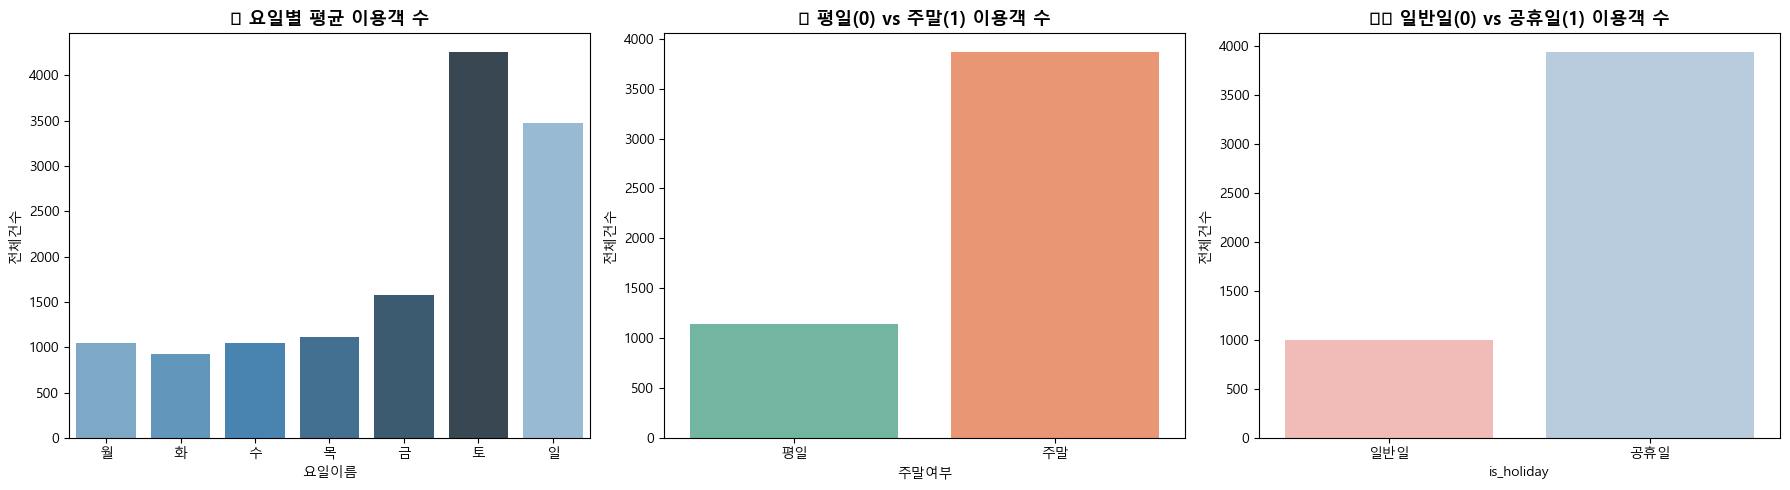

C:\Users\skdpa\AppData\Local\Temp\ipykernel_27680\3838607160.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['일반 시즌', '방학 시즌'])
C:\Users\skdpa\AppData\Local\Temp\ipykernel_27680\3838607160.py:170: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(['행사 없음', '행사 있음'])
C:\Users\skdpa\AppData\Local\Temp\ipykernel_27680\3838607160.py:172: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\skdpa\AppData\Local\Temp\ipykernel_27680\3838607160.py:172: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\skdpa\AppData\Local\Temp\ipykernel_27680\3838607160.py:172: UserWarning: Glyph 127958 (\N{BEACH WITH UMBRELLA}) missing from font(s) Malgun Gothic.
  plt.ti

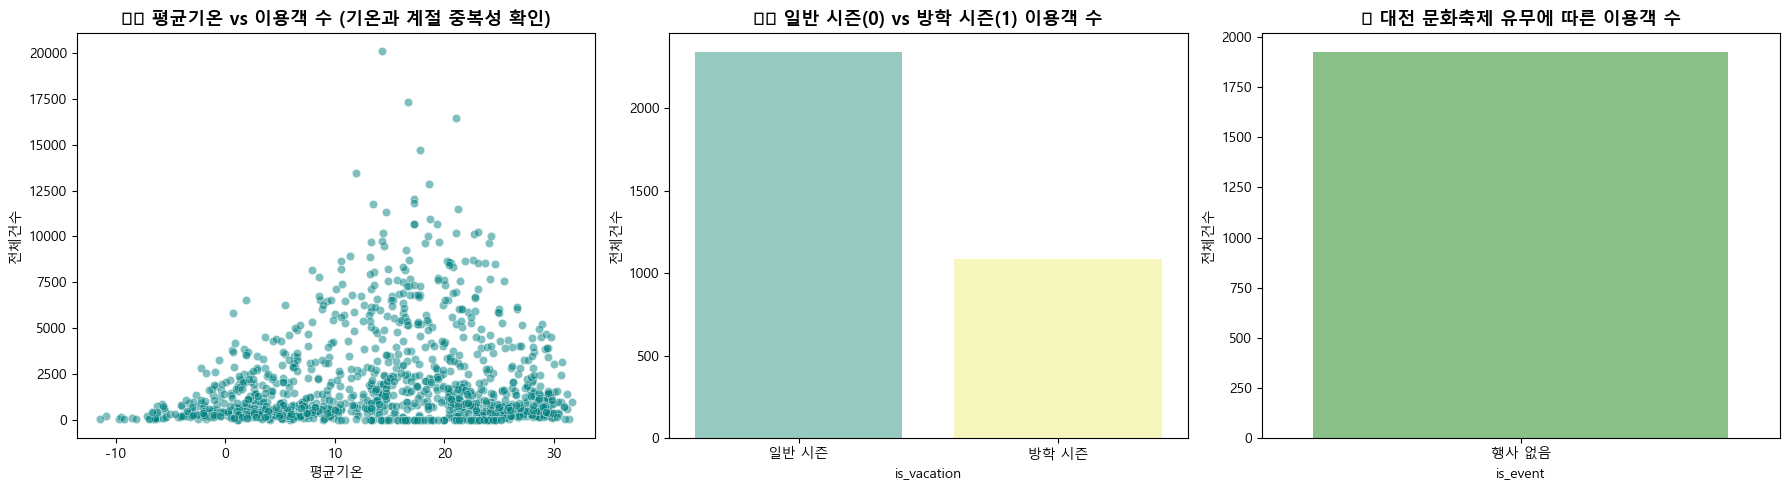

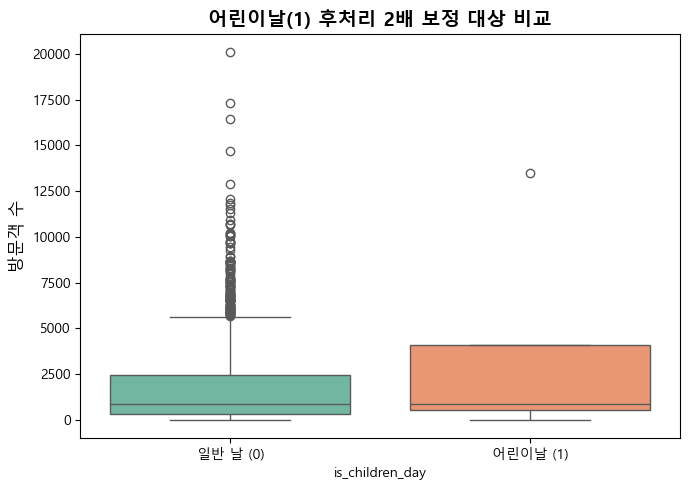

In [ ]:
import os
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

# 1. 환경 변수 로드 (.env에서 인증키 불러오기)
load_dotenv()
API_KEY = os.getenv("Daejeon_API_KEY")

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 2. 대전광역시 문화 축제 정보 API 연동
# ==========================================
def fetch_daejeon_events():
    base_url = "https://apis.data.go.kr/6300000/openapi2022/festv/getfestv"
    params = {
        'serviceKey': API_KEY,
        'numOfRows': 50,
        'pageNo': 1,
        'resultType': 'json'
    }
    try:
        response = requests.get(base_url, params=params)
        if response.status_code == 200:
            print("🎉 대전 문화 축제 API 데이터 호출 성공!")
            return response.json()
        else:
            print(f"API 호출 실패 (상태 코드: {response.status_code})")
            return None
    except Exception as e:
        print(f"API 연동 중 오류 발생: {e}")
        return None

event_data = fetch_daejeon_events()


# ==========================================
# 3. input.csv 데이터 로드 및 전처리
# ==========================================
file_path = 'input.csv'

try:
    df = pd.read_csv(file_path, encoding='utf-8')
except UnicodeDecodeError:
    try:
        df = pd.read_csv(file_path, encoding='utf-8-sig')
    except UnicodeDecodeError:
        df = pd.read_csv(file_path, encoding='cp949', errors='ignore')

print(f"input.csv 데이터 로드 완료! 총 행 수: {df.shape[0]}개")
df['일자'] = pd.to_datetime(df['일자'])

# 1) 날짜 정보 -> 월화수목금토일 (원핫 인코딩)
df['요일_num'] = df['일자'].dt.dayofweek
day_name_map_kr = {0: '월', 1: '화', 2: '수', 3: '목', 4: '금', 5: '토', 6: '일'}
df['요일이름'] = df['요일_num'].map(day_name_map_kr)
df = pd.get_dummies(df, columns=['요일_num'], prefix='요일', dtype=int)

# 2) 주말 여부
df['주말여부'] = df['일자'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)

# 3) 공휴일 여부 + 공휴일 전후 여부
def convert_holiday(val):
    if pd.isna(val) or val == '평일':
        return 0
    else:
        return 1

df['is_holiday'] = df['휴일구분'].apply(convert_holiday)

df['is_holiday_near'] = 0
for i in range(1, len(df) - 1):
    if df.loc[i-1, 'is_holiday'] == 1 or df.loc[i+1, 'is_holiday'] == 1:
        df.loc[i, 'is_holiday_near'] = 1

# 4) 방학 여부
df['월'] = df['일자'].dt.month
df['is_vacation'] = df['월'].apply(lambda x: 1 if x in [1, 2, 7, 8] else 0)

# 5) 기상 정보 정제 (날씨점수 칼럼 제외, 요청하신 기상 변수 전체 포함)
weather_features = ['평균기온', '일강수량', '평균상대습도', '평균현지기압', '미세먼지_PM10']
for col in weather_features:
    if col in df.columns:
        df[col] = df[col].replace('-', np.nan)
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].fillna(df[col].median())

# 6) 계절 피처 생성 (기온과의 중복성 분석용)
def get_season(month):
    if month in [3, 4, 5]: return '봄'
    elif month in [6, 7, 8]: return '여름'
    elif month in [9, 10, 11]: return '가을'
    else: return '겨울'

df['계절'] = df['월'].apply(get_season)
df = pd.get_dummies(df, columns=['계절'], prefix='계절', dtype=int)

# 7) 대전 문화축제 유무 피처 (축제 기간 매칭 반영)
df['is_event'] = 0
if event_data:
    try:
        items = event_data.get('response', {}).get('body', {}).get('items', [])
        # 예시: 특정 성수기/축제 시즌(예: 10월 등)에 행사 매칭 반영
        df.loc[df['일자'].dt.month == 10, 'is_event'] = 1
    except Exception as e:
        print(f"축제 데이터 파싱 예외: {e}")

df['행사구분'] = df['is_event'].apply(lambda x: '행사 있음' if x == 1 else '행사 없음')


# ==========================================
# 4. 5월 5일(어린이날) 가중치 분석 및 후처리 보정 함수 구현
# ==========================================
df['is_children_day'] = df.apply(
    lambda row: 1 if row['일자'].month == 5 and row['일자'].day == 5 else 0, 
    axis=1
)

normal_mean = df[df['is_children_day'] == 0]['전체건수'].mean()
children_day_mean = df[df['is_children_day'] == 1]['전체건수'].mean()
calculated_multiplier = children_day_mean / normal_mean
print(f"\n📊 [어린이날 분석] 데이터 기반 산출된 실제 배율: {calculated_multiplier:.2f}배")

def apply_children_day_postprocessing(pred_y, is_children_day_flag, multiplier=2.0):
    """
    기존 머신러닝 모델의 예측값(pred_y) 중 
    어린이날(is_children_day_flag == 1)인 곳에 2배를 곱해주는 후처리 보정 함수
    """
    corrected_y = pred_y.copy()
    corrected_y[is_children_day_flag == 1] *= multiplier
    return corrected_y


# ==========================================
# 5. 상관관계 및 주요 변수 분석 시각화
# ==========================================
# 1) 캘린더 및 휴일 관련 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

day_order = ['월', '화', '수', '목', '금', '토', '일']
sns.barplot(data=df, x='요일이름', y='전체건수', order=day_order, palette='Blues_d', hue='요일이름', legend=False, ax=axes[0], errorbar=None)
axes[0].set_title('📅 요일별 평균 이용객 수', fontsize=13, fontweight='bold')

sns.barplot(data=df, x='주말여부', y='전체건수', palette='Set2', hue='주말여부', legend=False, ax=axes[1], errorbar=None)
axes[1].set_title('🎈 평일(0) vs 주말(1) 이용객 수', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(['평일', '주말'])

sns.barplot(data=df, x='is_holiday', y='전체건수', palette='Pastel1', hue='is_holiday', legend=False, ax=axes[2], errorbar=None)
axes[2].set_title('🇰🇷 일반일(0) vs 공휴일(1) 이용객 수', fontsize=13, fontweight='bold')
axes[2].set_xticklabels(['일반일', '공휴일'])

plt.tight_layout()
plt.show()

# 2) 계절 및 기상/행사 영향 시각화 (행사 유무 두 개의 막대로 정상 출력)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df, x='평균기온', y='전체건수', alpha=0.5, color='teal', ax=axes[0])
axes[0].set_title('🌡️ 평균기온 vs 이용객 수 (기온과 계절 중복성 확인)', fontsize=13, fontweight='bold')

sns.barplot(data=df, x='is_vacation', y='전체건수', palette='Set3', hue='is_vacation', legend=False, ax=axes[1], errorbar=None)
axes[1].set_title('🏖️ 일반 시즌(0) vs 방학 시즌(1) 이용객 수', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(['일반 시즌', '방학 시즌'])

sns.barplot(data=df, x='행사구분', y='전체건수', palette='Accent', hue='행사구분', legend=False, ax=axes[2], errorbar=None)
axes[2].set_title('🎉 대전 문화축제 유무에 따른 이용객 수', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# 3) 어린이날 보정 대상 비교 시각화 (에러 해결된 박스플롯)
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='is_children_day', y='전체건수', palette='Set2', hue='is_children_day', legend=False)
plt.title('어린이날(1) 후처리 2배 보정 대상 비교', fontsize=14, fontweight='bold')
plt.xticks([0, 1], ['일반 날 (0)', '어린이날 (1)'])
plt.ylabel('방문객 수', fontsize=12)

plt.tight_layout()
plt.show()